## Starting the Accra Air Quality Analysis
importing the necessary libraries

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Loading the data file to work with

In [2]:
df = pd.read_csv('../data/accra_air_quality.csv')

## Finding out the number of rows and collumns 

In [3]:
df.shape

(30, 12)

## Looking at the first five sets of data in the table to understand the nature of the data we are coming to work with

In [4]:
df.head()


,station_id,station_name,month,month_num,PM2_5_ugm3,PM10_ugm3,NO2_ppb,CO_ppm,temperature_C,humidity_pct,wind_speed_ms,aqi_category
0,ST01,Kaneshie Market,January,1,89.4,142.1,48.2,1.8,27.4,68,1.2,Unhealthy
1,ST01,Kaneshie Market,February,2,94.2,151.8,52.1,2.1,28.1,65,1.0,Unhealthy
2,ST01,Kaneshie Market,March,3,78.6,128.4,44.8,1.6,29.8,58,1.8,Unhealthy
3,ST01,Kaneshie Market,April,4,82.1,134.2,46.3,1.7,30.2,55,1.6,Unhealthy
4,ST01,Kaneshie Market,May,5,71.4,118.6,41.2,1.4,31.4,52,2.1,Unhealthy for Sensitive Groups


## Checking for the datatypes of all the collumns so that we know whether to change some of them in other to do a smooth computation

In [5]:
df.dtypes

station_id        object
station_name      object
month             object
month_num          int64
PM2_5_ugm3       float64
PM10_ugm3        float64
NO2_ppb          float64
CO_ppm           float64
temperature_C    float64
humidity_pct       int64
wind_speed_ms    float64
aqi_category      object
dtype: object

## Checking for missing values. Any column with a count above zero requires a cleaning decision before analysis can proceed.

In [6]:
df.isnull().sum()

station_id       0
station_name     0
month            0
month_num        0
PM2_5_ugm3       0
PM10_ugm3        0
NO2_ppb          0
CO_ppm           0
temperature_C    0
humidity_pct     0
wind_speed_ms    0
aqi_category     0
dtype: int64

In [7]:
df.describe()

,month_num,PM2_5_ugm3,PM10_ugm3,NO2_ppb,CO_ppm,temperature_C,humidity_pct,wind_speed_ms
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,3.500000,72.866667,118.093333,42.286667,1.510000,28.556667,64.133333,2.253333
std,1.737021,49.106080,76.170091,27.989009,1.194917,2.518440,9.637332,1.497523
min,1.000000,10.800000,19.800000,6.400000,0.100000,22.400000,48.000000,0.500000
25%,2.000000,22.775000,41.300000,15.300000,0.300000,27.175000,55.500000,1.025000
50%,3.500000,80.350000,131.300000,45.550000,1.650000,29.250000,64.500000,1.800000
75%,5.000000,113.800000,182.150000,66.000000,2.475000,30.350000,70.000000,3.025000
max,6.000000,158.400000,248.200000,91.200000,3.800000,32.100000,84.000000,5.400000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.to_csv('../data/cleaned_accra_air_quality.csv', index=False)

### The dataset is clean and ready for analysis. We can proceed with exploratory data analysis (EDA) to understand the distribution of air quality parameters, identify trends, and visualize the data.

# Which stations are consistently above safe limits?

### PM2_5_ugm3 Analysis


In [10]:
pm25_summary = (
    df.groupby("station_id")["PM2_5_ugm3"]
    .agg(["mean", "max", "std"])
    #.sort_values(by="mean", ascending=False)
)

pm25_summary

,mean,max,std
station_id,,,
ST01,78.983333,94.2,12.956607
ST02,25.283333,31.2,4.435501
ST03,137.500000,158.4,16.066238
ST04,14.733333,18.2,2.773205
ST05,107.833333,124.8,15.341143


In [11]:
# 1. Group and summarize PM2.5 by station
pm25_summary = (
    df.groupby("station_id")["PM2_5_ugm3"]
    .agg(["mean", "max", "std"])
)

# 2. Sort by mean (typical exposure)
pm25_by_mean = pm25_summary.sort_values(by="mean", ascending=False)

# 3. Sort by max (extreme events)
pm25_by_max = pm25_summary.sort_values(by="max", ascending=False)

# 4. Sort by std (variability)
pm25_by_std = pm25_summary.sort_values(by="std", ascending=False)

# 6. Reset index if you want flat tables for plotting or exporting
pm25_by_mean = pm25_by_mean.reset_index()
pm25_by_max = pm25_by_max.reset_index()
pm25_by_std = pm25_by_std.reset_index()


# 7. Print or visualize
print("Ranking by Mean:\n", pm25_by_mean)
print("Ranking by Max:\n", pm25_by_max)
print("Ranking by Std:\n", pm25_by_std)


Ranking by Mean:
   station_id        mean    max        std
0       ST03  137.500000  158.4  16.066238
1       ST05  107.833333  124.8  15.341143
2       ST01   78.983333   94.2  12.956607
3       ST02   25.283333   31.2   4.435501
4       ST04   14.733333   18.2   2.773205
Ranking by Max:
   station_id        mean    max        std
0       ST03  137.500000  158.4  16.066238
1       ST05  107.833333  124.8  15.341143
2       ST01   78.983333   94.2  12.956607
3       ST02   25.283333   31.2   4.435501
4       ST04   14.733333   18.2   2.773205
Ranking by Std:
   station_id        mean    max        std
0       ST03  137.500000  158.4  16.066238
1       ST05  107.833333  124.8  15.341143
2       ST01   78.983333   94.2  12.956607
3       ST02   25.283333   31.2   4.435501
4       ST04   14.733333   18.2   2.773205


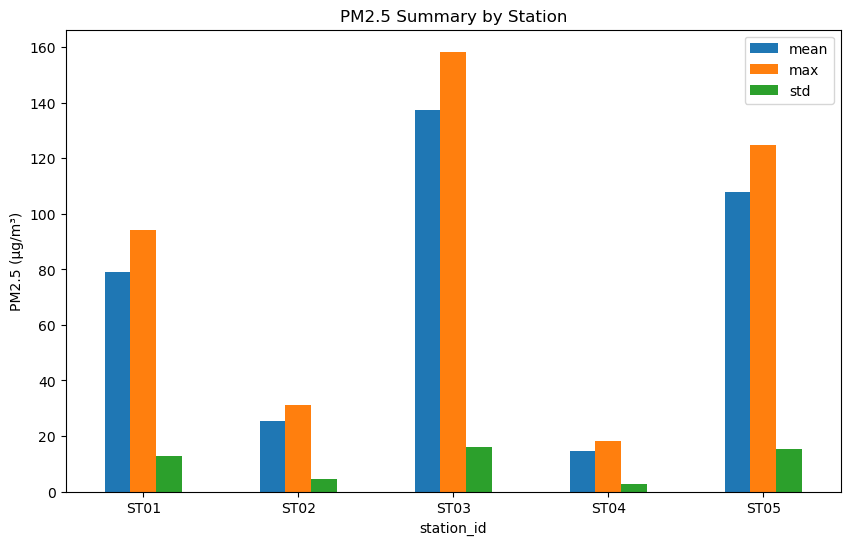

In [12]:
import matplotlib.pyplot as plt

# Bar chart for mean, max, std side by side
pm25_summary.plot(kind="bar", figsize=(10,6))
plt.title("PM2.5 Summary by Station")
plt.ylabel("PM2.5 (µg/m³)")
plt.xticks(rotation=0)
plt.show()


Summarize WHO standards and compare with your station means.

In [13]:
pm25_summary["WHO_limit"] = 15
pm25_summary["Exceedance_factor"] = pm25_summary["mean"] / pm25_summary["WHO_limit"]


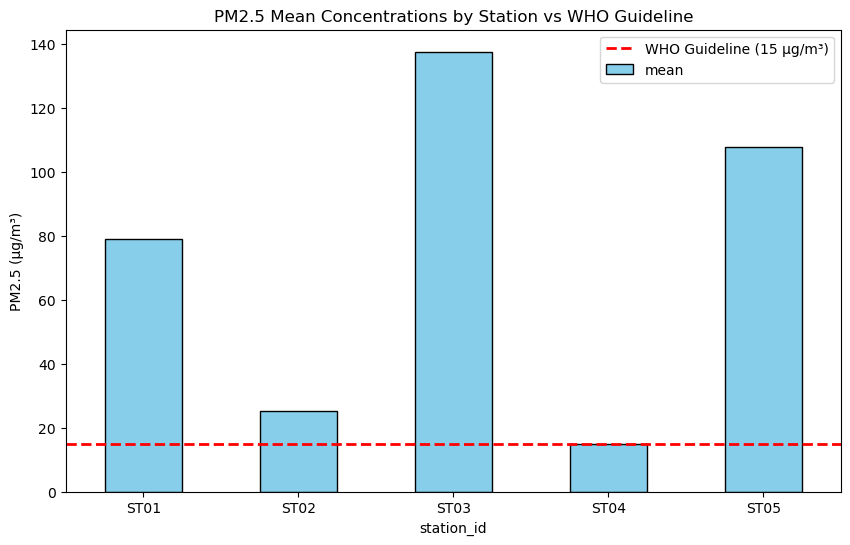

In [14]:
import matplotlib.pyplot as plt

# WHO guideline for PM2.5 annual mean
WHO_limit = 15

# Plot mean values as bars
pm25_summary["mean"].plot(kind="bar", figsize=(10,6), color="skyblue", edgecolor="black")

# Add WHO guideline line
plt.axhline(y=WHO_limit, color="red", linestyle="--", linewidth=2, label="WHO Guideline (15 µg/m³)")

# Titles and labels
plt.title("PM2.5 Mean Concentrations by Station vs WHO Guideline")
plt.ylabel("PM2.5 (µg/m³)")
plt.xticks(range(len(pm25_summary)), pm25_summary.index, rotation=0)

# Legend
plt.legend()

plt.show()


# PM10_ugm3 Analysis


In [15]:
# 1. Group and summarize PM10 by station
PM10_ugm3_summary = (
    df.groupby("station_id")["PM10_ugm3"]
    .agg(["mean", "max", "std"])
)

# 2. Sort by mean (typical exposure)
PM10_by_mean = PM10_ugm3_summary.sort_values(by="mean", ascending=False)

# 3. Sort by max (extreme events)
PM10_by_max = PM10_ugm3_summary.sort_values(by="max", ascending=False)

# 4. Sort by std (variability)
PM10_by_std = PM10_ugm3_summary.sort_values(by="std", ascending=False)

# 6. Reset index if you want flat tables for plotting or exporting
PM10_by_mean = PM10_by_mean.reset_index()   
PM10_by_max = PM10_by_max.reset_index()
PM10_by_std = PM10_by_std.reset_index()

# 7. Print or visualize
print("PM10 Ranking by Mean:\n", PM10_by_mean)
print("PM10 Ranking by Max:\n", PM10_by_max)
print("PM10 Ranking by Std:\n", PM10_by_std)


PM10 Ranking by Mean:
   station_id        mean    max        std
0       ST03  217.666667  248.2  23.201954
1       ST05  172.766667  198.2  23.107892
2       ST01  128.916667  151.8  18.779395
3       ST02   44.433333   52.4   6.354106
4       ST04   26.683333   32.4   4.719499
PM10 Ranking by Max:
   station_id        mean    max        std
0       ST03  217.666667  248.2  23.201954
1       ST05  172.766667  198.2  23.107892
2       ST01  128.916667  151.8  18.779395
3       ST02   44.433333   52.4   6.354106
4       ST04   26.683333   32.4   4.719499
PM10 Ranking by Std:
   station_id        mean    max        std
0       ST03  217.666667  248.2  23.201954
1       ST05  172.766667  198.2  23.107892
2       ST01  128.916667  151.8  18.779395
3       ST02   44.433333   52.4   6.354106
4       ST04   26.683333   32.4   4.719499


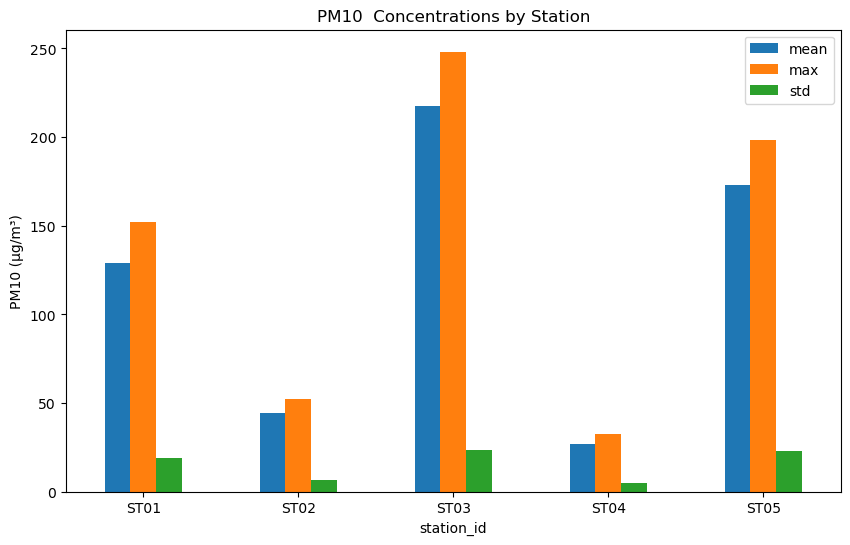

In [16]:
# Bar chart for PM10 summary values
PM10_ugm3_summary.plot(kind="bar", figsize=(10,6))
plt.title("PM10  Concentrations by Station")
plt.ylabel("PM10 (µg/m³)")
plt.xticks(rotation=0)  
plt.show()



Summarize WHO standards and compare with station PM10 means.

In [17]:
# Add WHO standards

PM10_ugm3_summary["WHO_limit"] = 45
PM10_ugm3_summary["Exceedance_factor"] = PM10_ugm3_summary["mean"] / PM10_ugm3_summary["WHO_limit"]


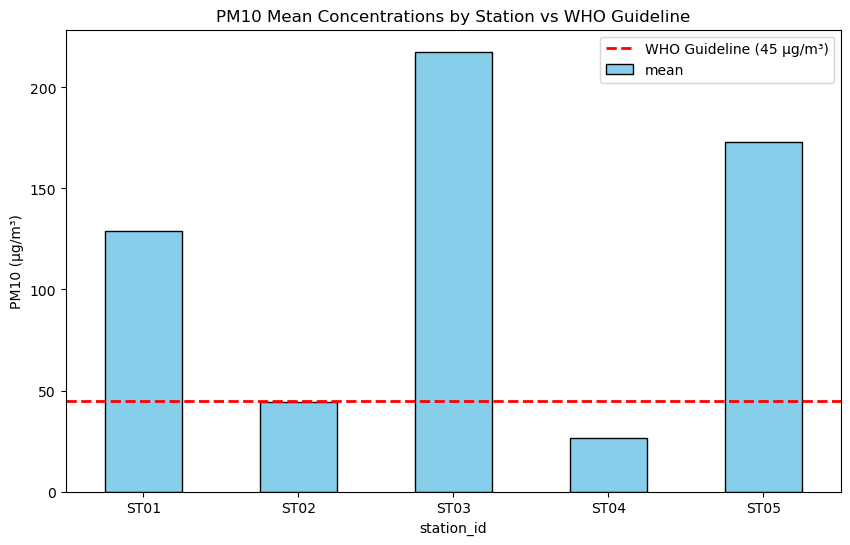

In [18]:


# WHO guideline for PM10 annual mean
WHO_limit = 45

# Plot mean values as bars
PM10_ugm3_summary["mean"].plot(kind="bar", figsize=(10,6), color="skyblue", edgecolor="black")

# Add WHO guideline line
plt.axhline(y=WHO_limit, color="red", linestyle="--", linewidth=2, label="WHO Guideline (45 µg/m³)")

# Titles and labels
plt.title("PM10 Mean Concentrations by Station vs WHO Guideline")
plt.ylabel("PM10 (µg/m³)")
plt.xticks(range(len(PM10_ugm3_summary)), PM10_ugm3_summary.index, rotation=0)

# Legend
plt.legend()

plt.show()


# NO2_ppb Analysis

In [19]:
df.head()

,station_id,station_name,month,month_num,PM2_5_ugm3,PM10_ugm3,NO2_ppb,CO_ppm,temperature_C,humidity_pct,wind_speed_ms,aqi_category
0,ST01,Kaneshie Market,January,1,89.4,142.1,48.2,1.8,27.4,68,1.2,Unhealthy
1,ST01,Kaneshie Market,February,2,94.2,151.8,52.1,2.1,28.1,65,1.0,Unhealthy
2,ST01,Kaneshie Market,March,3,78.6,128.4,44.8,1.6,29.8,58,1.8,Unhealthy
3,ST01,Kaneshie Market,April,4,82.1,134.2,46.3,1.7,30.2,55,1.6,Unhealthy
4,ST01,Kaneshie Market,May,5,71.4,118.6,41.2,1.4,31.4,52,2.1,Unhealthy for Sensitive Groups


In [20]:
# group and summarize NO2 by station
NO2_summary = (
    df.groupby("station_id")["NO2_ppb"]
    .agg(["mean", "max", "std"])
    #.sort_values(by="mean", ascending=False)
)
NO2_summary

# Sort by mean NO2
NO2_by_mean = NO2_summary.sort_values(by="mean", ascending=False)

# Sort by max NO2
NO2_by_max = NO2_summary.sort_values(by="max", ascending=False)

# Sort by std NO2
NO2_by_std = NO2_summary.sort_values(by="std", ascending=False)

# Reset index for flat tables
NO2_by_mean = NO2_by_mean.reset_index()
NO2_by_max = NO2_by_max.reset_index()
NO2_by_std = NO2_by_std.reset_index()

# Print results
print("NO2 Ranking by Mean:\n", NO2_by_mean)
print("NO2 Ranking by Max:\n", NO2_by_max)
print("NO2 Ranking by Std:\n", NO2_by_std)



NO2 Ranking by Mean:
   station_id       mean   max       std
0       ST03  79.600000  91.2  9.357778
1       ST05  62.383333  72.1  8.725690
2       ST01  44.450000  52.1  6.225994
3       ST02  16.650000  20.1  2.721580
4       ST04   8.350000  10.2  1.422322
NO2 Ranking by Max:
   station_id       mean   max       std
0       ST03  79.600000  91.2  9.357778
1       ST05  62.383333  72.1  8.725690
2       ST01  44.450000  52.1  6.225994
3       ST02  16.650000  20.1  2.721580
4       ST04   8.350000  10.2  1.422322
NO2 Ranking by Std:
   station_id       mean   max       std
0       ST03  79.600000  91.2  9.357778
1       ST05  62.383333  72.1  8.725690
2       ST01  44.450000  52.1  6.225994
3       ST02  16.650000  20.1  2.721580
4       ST04   8.350000  10.2  1.422322


# Plot the insight from the data derived by the groups

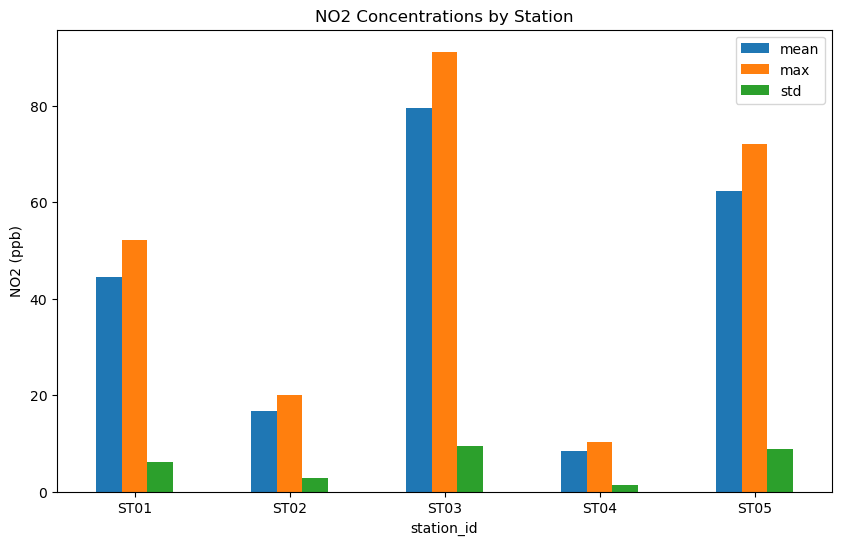

In [21]:
# Bar chart for NO2 summary values
NO2_summary.plot(kind="bar", figsize=(10,6))
plt.title("NO2 Concentrations by Station")
plt.ylabel("NO2 (ppb)")
plt.xticks(rotation=0)
plt.show()

# Comparing the values to WHO guidelines


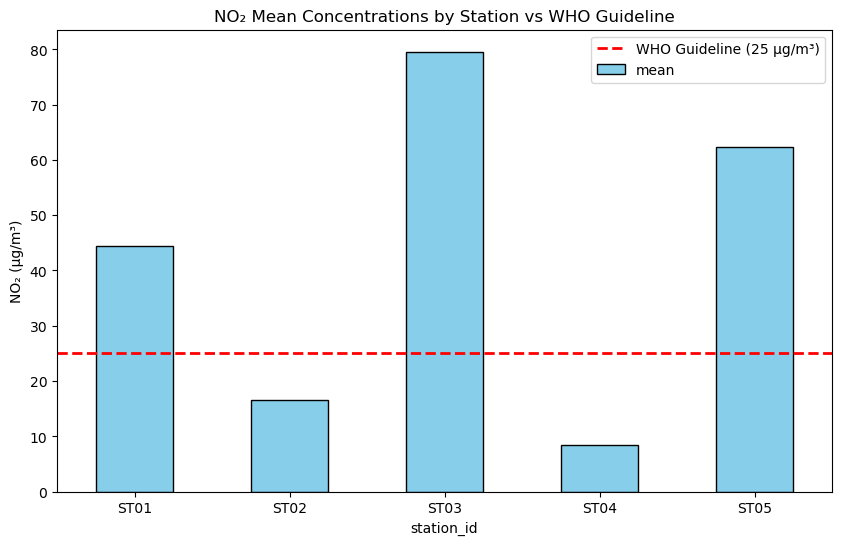

In [22]:



WHO_limit = 25

# Plot mean values as bars
NO2_summary["mean"].plot(kind="bar", figsize=(10,6), color="skyblue", edgecolor="black")

# Add WHO guideline line
plt.axhline(y=WHO_limit, color="red", linestyle="--", linewidth=2, label="WHO Guideline (25 µg/m³)")

# Titles and labels
plt.title("NO₂ Mean Concentrations by Station vs WHO Guideline")
plt.ylabel("NO₂ (µg/m³)")
plt.xticks(range(len(NO2_summary)), NO2_summary.index, rotation=0)

# Legend
plt.legend()

plt.show()



# CO_ppm Analysis

In [23]:
# Group and summarize CO by station
CO_summary = (
    df.groupby("station_id")["CO_ppm"]
    .agg(["mean", "max", "std"])
)

CO_summary

,mean,max,std
station_id,,,
ST01,1.616667,2.1,0.343026
ST02,0.350000,0.5,0.104881
ST03,3.100000,3.8,0.485798
ST04,0.133333,0.2,0.051640
ST05,2.350000,2.8,0.361939


In [24]:
# Sort by mean CO
CO_by_mean = CO_summary.sort_values(by="mean", ascending=False)

# Sort by max CO
CO_by_max = CO_summary.sort_values(by="max", ascending=False)

# Sort by std CO
CO_by_std = CO_summary.sort_values(by="std", ascending=False)

# Reset index for flat tables
CO_by_mean = CO_by_mean.reset_index()
CO_by_max = CO_by_max.reset_index()
CO_by_std = CO_by_std.reset_index()

# Print results
print("CO Ranking by Mean:\n", CO_by_mean)
print("CO Ranking by Max:\n", CO_by_max)
print("CO Ranking by Std:\n", CO_by_std)
    

CO Ranking by Mean:
   station_id      mean  max       std
0       ST03  3.100000  3.8  0.485798
1       ST05  2.350000  2.8  0.361939
2       ST01  1.616667  2.1  0.343026
3       ST02  0.350000  0.5  0.104881
4       ST04  0.133333  0.2  0.051640
CO Ranking by Max:
   station_id      mean  max       std
0       ST03  3.100000  3.8  0.485798
1       ST05  2.350000  2.8  0.361939
2       ST01  1.616667  2.1  0.343026
3       ST02  0.350000  0.5  0.104881
4       ST04  0.133333  0.2  0.051640
CO Ranking by Std:
   station_id      mean  max       std
0       ST03  3.100000  3.8  0.485798
1       ST05  2.350000  2.8  0.361939
2       ST01  1.616667  2.1  0.343026
3       ST02  0.350000  0.5  0.104881
4       ST04  0.133333  0.2  0.051640


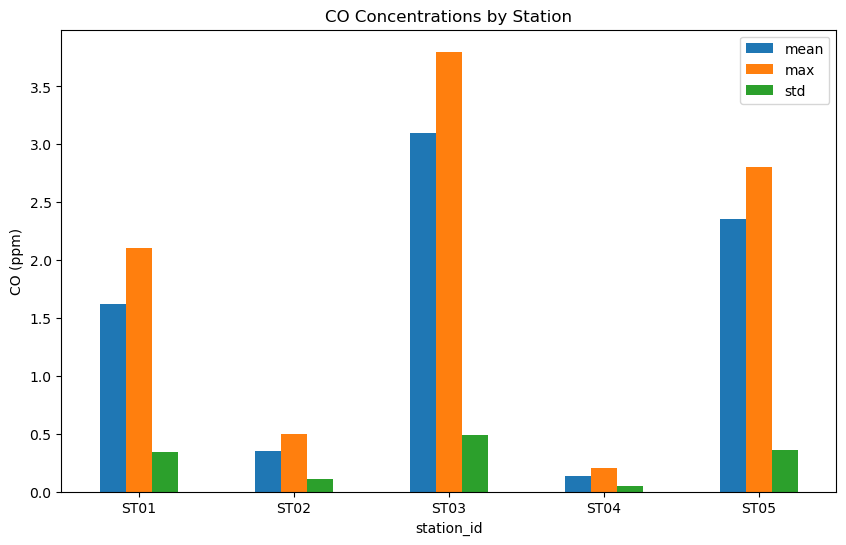

In [25]:
# Bar chart for CO summary values
CO_summary.plot(kind="bar", figsize=(10,6))
plt.title("CO Concentrations by Station")  
plt.ylabel("CO (ppm)")
plt.xticks(rotation=0)
plt.legend()
plt.show()


# Comparing the values to WHO guidelines

In [26]:
# Who safe limits for CO
who_CO_limits = 0.9

CO_summary["WHO_CO_limit"] = who_CO_limits
CO_summary["Exceedance_factor_mean"] = CO_summary["mean"] / CO_summary["WHO_CO_limit"]
CO_summary


,mean,max,std,WHO_CO_limit,Exceedance_factor_mean
station_id,,,,,
ST01,1.616667,2.1,0.343026,0.9,1.796296
ST02,0.350000,0.5,0.104881,0.9,0.388889
ST03,3.100000,3.8,0.485798,0.9,3.444444
ST04,0.133333,0.2,0.051640,0.9,0.148148
ST05,2.350000,2.8,0.361939,0.9,2.611111


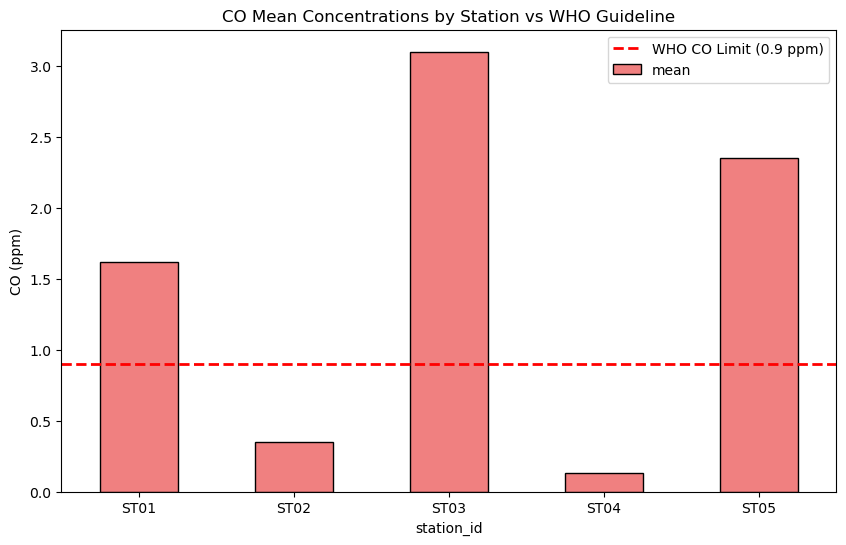

In [27]:
# Plot the CO mean values with WHO guideline


CO_summary["mean"].plot(kind="bar", figsize=(10,6), color="lightcoral", edgecolor="black")
plt.title("CO Mean Concentrations by Station vs WHO Guideline")
plt.axhline(y=who_CO_limits, color="red", linestyle="--", linewidth=2,
            label="WHO CO Limit (0.9 ppm)")
plt.ylabel("CO (ppm)")
plt.xticks(rotation=0)
plt.legend()
plt.title("CO Mean Concentrations by Station vs WHO Guideline")
plt.show()  


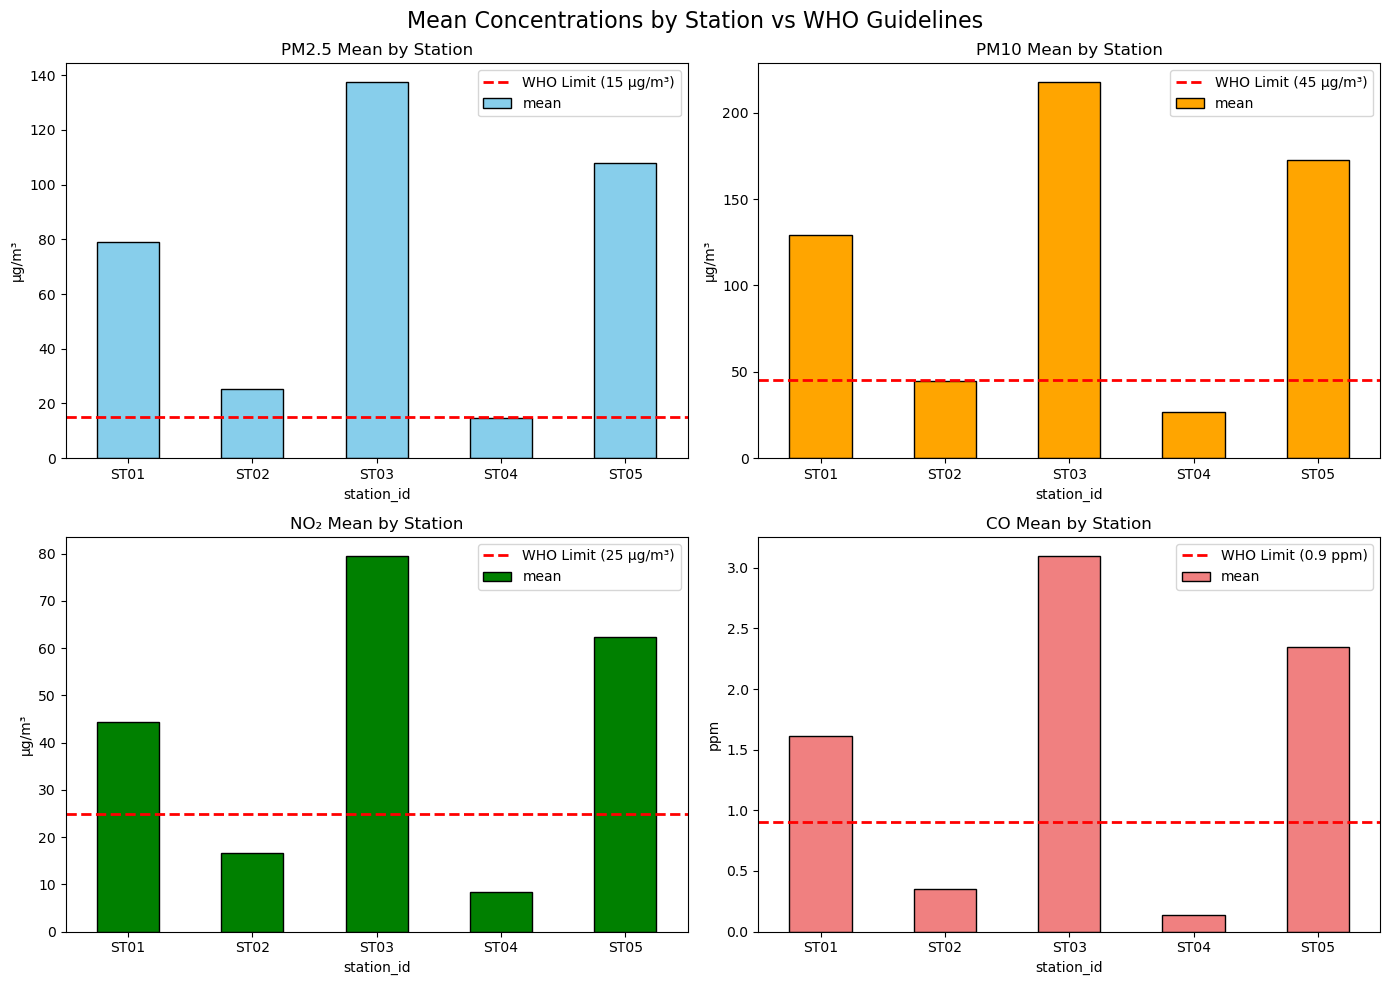

In [28]:
import matplotlib.pyplot as plt

# WHO guideline values
who_limits = {
    "PM2.5": 15,   # µg/m³ annual mean
    "PM10": 45,    # µg/m³ annual mean
    "NO2": 25,     # µg/m³ annual mean
    "CO": 0.9      # ppm
}

# Create subplots: 2 rows × 2 columns
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# PM2.5
pm25_summary["mean"].plot(kind="bar", ax=axes[0,0], color="skyblue", edgecolor="black")
axes[0,0].axhline(y=who_limits["PM2.5"], color="red", linestyle="--", linewidth=2,
                  label=f"WHO Limit ({who_limits['PM2.5']} µg/m³)")
axes[0,0].set_title("PM2.5 Mean by Station")
axes[0,0].set_ylabel("µg/m³")
axes[0,0].legend()
axes[0,0].set_xticklabels(pm25_summary.index, rotation=0)

# PM10
PM10_ugm3_summary["mean"].plot(kind="bar", ax=axes[0,1], color="orange", edgecolor="black")
axes[0,1].axhline(y=who_limits["PM10"], color="red", linestyle="--", linewidth=2,
                  label=f"WHO Limit ({who_limits['PM10']} µg/m³)")
axes[0,1].set_title("PM10 Mean by Station")
axes[0,1].set_ylabel("µg/m³")
axes[0,1].legend()
axes[0,1].set_xticklabels(PM10_ugm3_summary.index, rotation=0)

# NO2
NO2_summary["mean"].plot(kind="bar", ax=axes[1,0], color="green", edgecolor="black")
axes[1,0].axhline(y=who_limits["NO2"], color="red", linestyle="--", linewidth=2,
                  label=f"WHO Limit ({who_limits['NO2']} µg/m³)")
axes[1,0].set_title("NO₂ Mean by Station")
axes[1,0].set_ylabel("µg/m³")
axes[1,0].legend()
axes[1,0].set_xticklabels(NO2_summary.index, rotation=0)

# CO
CO_summary["mean"].plot(kind="bar", ax=axes[1,1], color="lightcoral", edgecolor="black")
axes[1,1].axhline(y=who_limits["CO"], color="red", linestyle="--", linewidth=2,
                  label=f"WHO Limit ({who_limits['CO']} ppm)")
axes[1,1].set_title("CO Mean by Station")
axes[1,1].set_ylabel("ppm")
axes[1,1].legend()
axes[1,1].set_xticklabels(CO_summary.index, rotation=0)

plt.suptitle("Mean Concentrations by Station vs WHO Guidelines", fontsize=16)
plt.tight_layout()
plt.show()


# Mean Concentrations by Station vs WHO Guidelines

## Visual Evidence (Bar Charts)
- Each pollutant (PM2.5, PM10, NO₂, CO) is shown as mean values across five monitoring stations (ST01–ST05).  
- WHO guideline limits are marked with red dashed lines for comparison.  
- Stations **ST03 and ST05** consistently record the highest mean concentrations across all pollutants.  
- Stations **ST02 and ST04** show much lower values, with ST04 often near or below the WHO limit.

## Interpretation
- **PM2.5 and PM10:** ST03 and ST05 exceed WHO limits by very large margins, indicating severe particulate pollution.  
- **NO₂:** ST03, ST05, and ST01 all exceed the WHO limit, while ST02 and ST04 remain below.  
- **CO:** ST03 and ST05 again exceed the limit, while ST02 and ST04 are well below.  
- The pattern shows that pollution is **not evenly distributed** — certain stations (ST03, ST05) are hotspots of consistently high concentrations.

## Conclusion
- **Yes, pollutant concentrations vary measurably by station.**  
- ST03 and ST05 are the most polluted sites, exceeding WHO guidelines across all pollutants.  
- ST02 and ST04 record much lower concentrations, sometimes within safe limits.  
- This highlights the importance of **location-specific monitoring and interventions

# Is there a seasonal pattern in pollution levels across the six-month period?

In [29]:
df.head()

,station_id,station_name,month,month_num,PM2_5_ugm3,PM10_ugm3,NO2_ppb,CO_ppm,temperature_C,humidity_pct,wind_speed_ms,aqi_category
0,ST01,Kaneshie Market,January,1,89.4,142.1,48.2,1.8,27.4,68,1.2,Unhealthy
1,ST01,Kaneshie Market,February,2,94.2,151.8,52.1,2.1,28.1,65,1.0,Unhealthy
2,ST01,Kaneshie Market,March,3,78.6,128.4,44.8,1.6,29.8,58,1.8,Unhealthy
3,ST01,Kaneshie Market,April,4,82.1,134.2,46.3,1.7,30.2,55,1.6,Unhealthy
4,ST01,Kaneshie Market,May,5,71.4,118.6,41.2,1.4,31.4,52,2.1,Unhealthy for Sensitive Groups


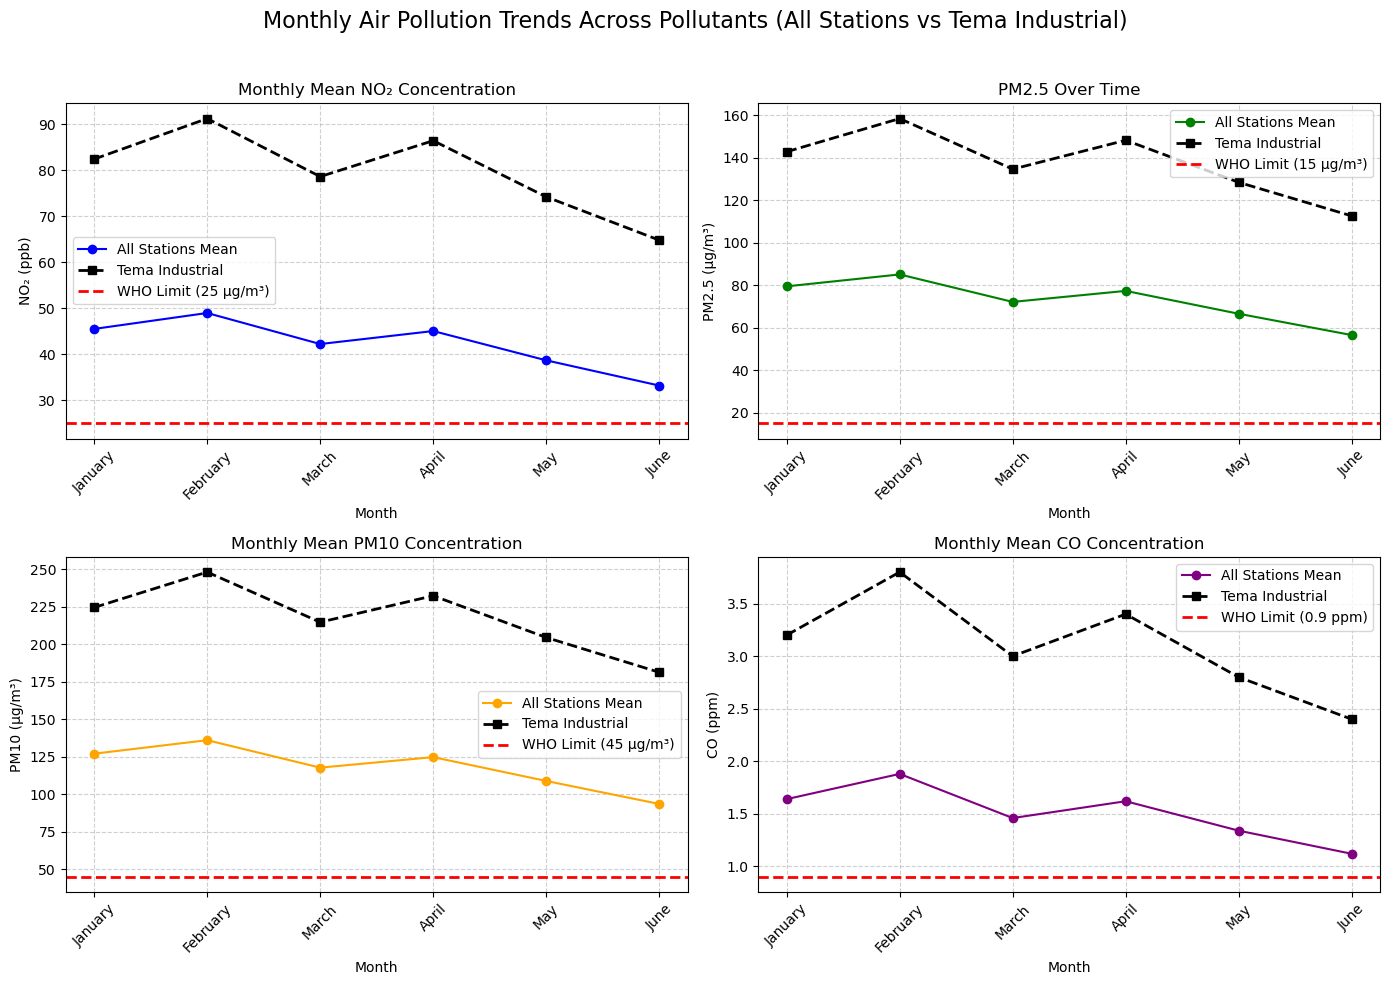

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# MONTH ORDER
# -----------------------------
month_order = ["January","February","March","April","May","June"]
df["month"] = pd.Categorical(df["month"], categories=month_order, ordered=True)

# -----------------------------
# Monthly summaries (all stations)
# -----------------------------
pm25_all = df.groupby("month", observed=True)["PM2_5_ugm3"].mean().reindex(month_order)
pm10_all = df.groupby("month", observed=True)["PM10_ugm3"].mean().reindex(month_order)
no2_all  = df.groupby("month", observed=True)["NO2_ppb"].mean().reindex(month_order)
co_all   = df.groupby("month", observed=True)["CO_ppm"].mean().reindex(month_order)

# Tema Industrial summaries (ST03)
pm25_tema = df[df["station_id"]=="ST03"].groupby("month", observed=True)["PM2_5_ugm3"].mean().reindex(month_order)
pm10_tema = df[df["station_id"]=="ST03"].groupby("month", observed=True)["PM10_ugm3"].mean().reindex(month_order)
no2_tema  = df[df["station_id"]=="ST03"].groupby("month", observed=True)["NO2_ppb"].mean().reindex(month_order)
co_tema   = df[df["station_id"]=="ST03"].groupby("month", observed=True)["CO_ppm"].mean().reindex(month_order)

# -----------------------------
# Consistent style for Tema Industrial
# -----------------------------
tema_color = "black"
tema_style = "--"
tema_marker = "s"

# -----------------------------
# Plotting
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

# NO2
axes[0].plot(no2_all.index, no2_all.values, marker="o", color="blue", label="All Stations Mean")
axes[0].plot(no2_tema.index, no2_tema.values, marker=tema_marker, linestyle=tema_style,
             color=tema_color, linewidth=2, label="Tema Industrial")
axes[0].axhline(y=25, linestyle="--", color="red", linewidth=2, label="WHO Limit (25 µg/m³)")
axes[0].set_title("Monthly Mean NO₂ Concentration")
axes[0].set_xlabel("Month"); axes[0].set_ylabel("NO₂ (ppb)")
axes[0].tick_params(axis="x", rotation=45); axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend()

# PM2.5
axes[1].plot(pm25_all.index, pm25_all.values, marker="o", color="green", label="All Stations Mean")
axes[1].plot(pm25_tema.index, pm25_tema.values, marker=tema_marker, linestyle=tema_style,
             color=tema_color, linewidth=2, label="Tema Industrial")
axes[1].axhline(y=15, linestyle="--", color="red", linewidth=2, label="WHO Limit (15 µg/m³)")
axes[1].set_title("PM2.5 Over Time")
axes[1].set_xlabel("Month"); axes[1].set_ylabel("PM2.5 (µg/m³)")
axes[1].tick_params(axis="x", rotation=45); axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].legend()

# PM10
axes[2].plot(pm10_all.index, pm10_all.values, marker="o", color="orange", label="All Stations Mean")
axes[2].plot(pm10_tema.index, pm10_tema.values, marker=tema_marker, linestyle=tema_style,
             color=tema_color, linewidth=2, label="Tema Industrial")
axes[2].axhline(y=45, linestyle="--", color="red", linewidth=2, label="WHO Limit (45 µg/m³)")
axes[2].set_title("Monthly Mean PM10 Concentration")
axes[2].set_xlabel("Month"); axes[2].set_ylabel("PM10 (µg/m³)")
axes[2].tick_params(axis="x", rotation=45); axes[2].grid(True, linestyle="--", alpha=0.6)
axes[2].legend()

# CO
axes[3].plot(co_all.index, co_all.values, marker="o", color="purple", label="All Stations Mean")
axes[3].plot(co_tema.index, co_tema.values, marker=tema_marker, linestyle=tema_style,
             color=tema_color, linewidth=2, label="Tema Industrial")
axes[3].axhline(y=0.9, linestyle="--", color="red", linewidth=2, label="WHO Limit (0.9 ppm)")
axes[3].set_title("Monthly Mean CO Concentration")
axes[3].set_xlabel("Month"); axes[3].set_ylabel("CO (ppm)")
axes[3].tick_params(axis="x", rotation=45); axes[3].grid(True, linestyle="--", alpha=0.6)
axes[3].legend()

# Layout
fig.suptitle("Monthly Air Pollution Trends Across Pollutants (All Stations vs Tema Industrial)", fontsize=16)
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()


# Monthly Air Pollution Trends Across Pollutants (All Stations vs Tema Industrial)

## Visual Evidence (Line Charts)
- All four pollutants (**NO₂, PM2.5, PM10, CO**) show a **declining trend** from January to June.  
- Both the **All Stations Mean** and **Tema Industrial** lines follow similar downward patterns, though Tema Industrial often starts at higher concentrations.  
- WHO guideline limits are consistently exceeded across the six-month period, even as levels decline.

## Interpretation
- The downward slopes indicate a **seasonal pattern**: pollution concentrations decrease as the months progress into mid-year.  
- This pattern is consistent across pollutants, suggesting that **seasonal factors (e.g., wind dispersion, rainfall, or reduced emissions)** influence air quality.  
- Tema Industrial highlights the trend clearly, showing elevated starting levels but still declining over time.

## Conclusion
- **Yes, there is a seasonal pattern in pollution levels.**  
- Concentrations of NO₂, PM2.5, PM10, and CO all **decrease from January to June**, but remain above WHO safety thresholds.  
- This demonstrates that while seasonal changes improve air quality, pollution remains a persistent health concern.


## Section 6 — Correlation Analysis
**This section answers Research Question 3: does temperature have a
measurable relationship with pollutant concentrations?**

Running a Pearson correlation matrix across PM2.5, temperature,
wind speed, and humidity. A negative correlation between wind speed
and PM2.5 would confirm that wind disperses pollutants — stations
with higher wind speeds should show lower pollution levels.

In [31]:
# Correlation matrix — PM2.5, temperature, wind speed, humidity
corr = df[['PM2_5_ugm3', 'temperature_C',
           'wind_speed_ms', 'humidity_pct']].corr().round(2)
print(corr)

               PM2_5_ugm3  temperature_C  wind_speed_ms  humidity_pct
PM2_5_ugm3           1.00           0.43          -0.88         -0.58
temperature_C        0.43           1.00          -0.57         -0.79
wind_speed_ms       -0.88          -0.57           1.00          0.63
humidity_pct        -0.58          -0.79           0.63          1.00


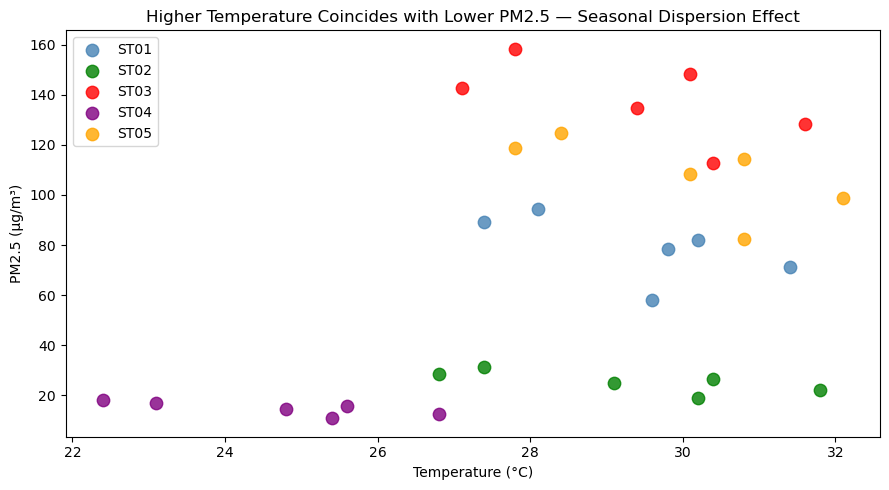

In [32]:
# Scatter plot — temperature vs PM2.5, coloured by station
fig, ax = plt.subplots(figsize=(9, 5))

colors_map = {'ST01':'steelblue','ST02':'green',
              'ST03':'red','ST04':'purple','ST05':'orange'}

for station, group in df.groupby('station_id'):
    ax.scatter(group['temperature_C'], group['PM2_5_ugm3'],
               label=station, color=colors_map[station],
               alpha=0.8, s=80)

ax.set_title('Higher Temperature Coincides with Lower PM2.5 — Seasonal Dispersion Effect')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.legend()
plt.tight_layout()
plt.savefig('../charts/chart_temperature_vs_pm25.png', dpi=150)
plt.show()

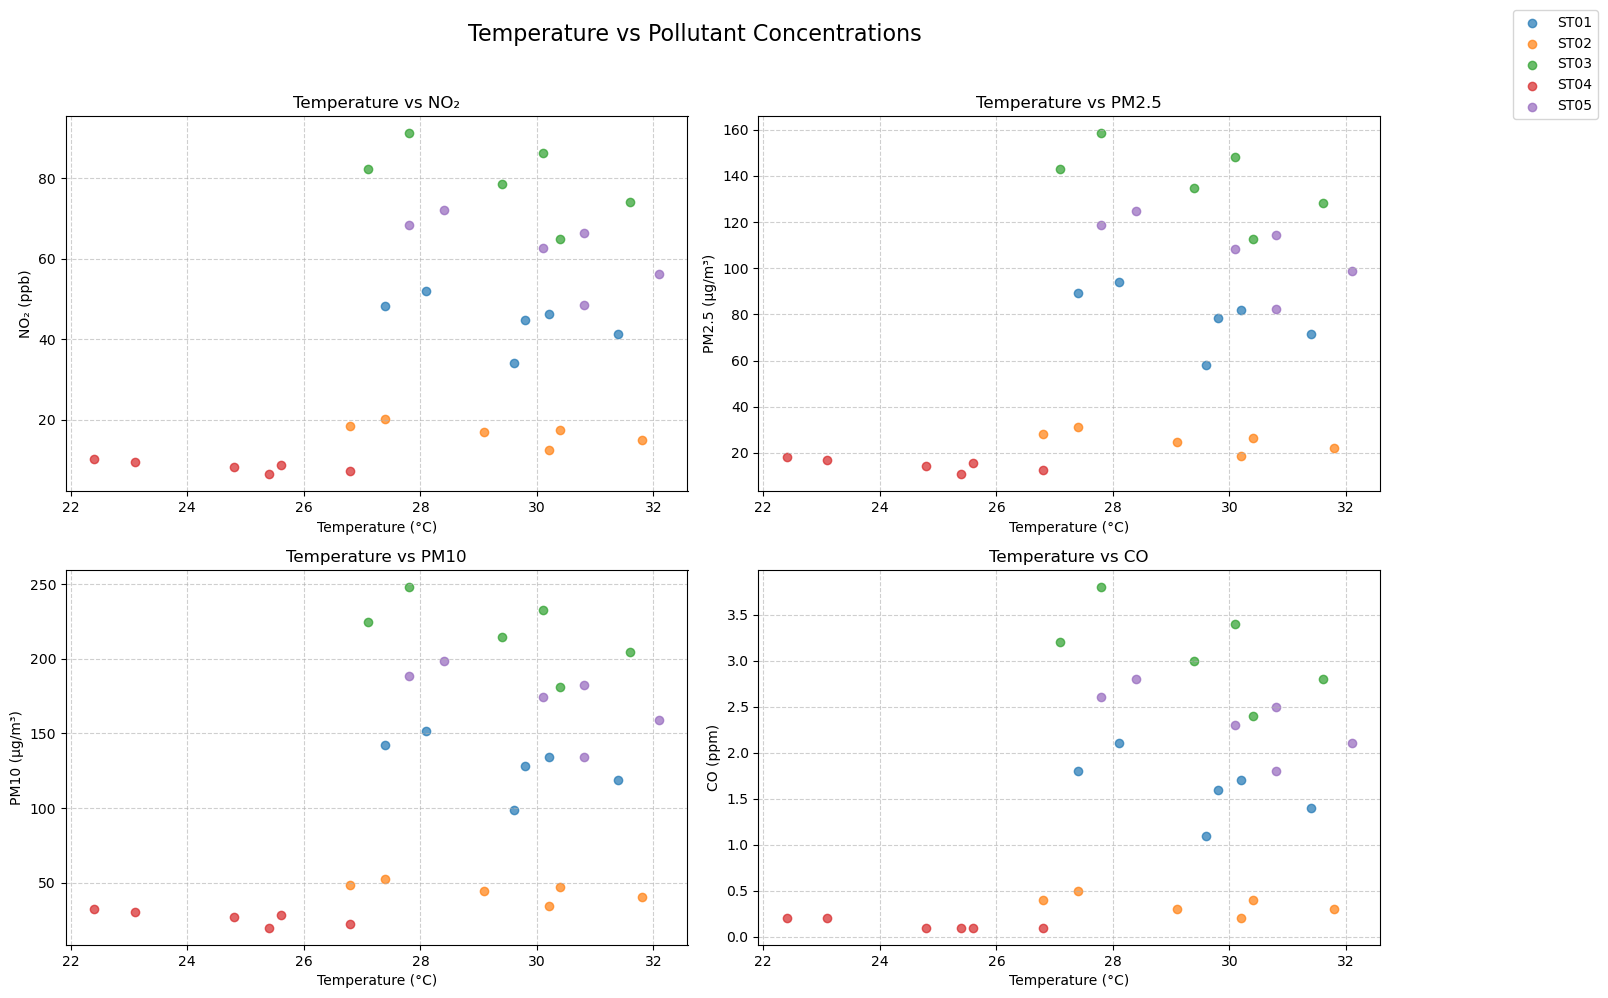

               temperature_C  NO2_ppb  PM2_5_ugm3  PM10_ugm3  CO_ppm
temperature_C           1.00     0.44        0.43       0.44    0.41
NO2_ppb                 0.44     1.00        1.00       1.00    1.00
PM2_5_ugm3              0.43     1.00        1.00       1.00    1.00
PM10_ugm3               0.44     1.00        1.00       1.00    1.00
CO_ppm                  0.41     1.00        1.00       1.00    1.00


In [33]:
import matplotlib.pyplot as plt

# -----------------------------
# Scatter plots: Temperature vs each pollutant
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes = axes.flatten()

# NO2
for station, group in df.groupby("station_id"):
    axes[0].scatter(group["temperature_C"], group["NO2_ppb"], label=station, alpha=0.7)
axes[0].set_title("Temperature vs NO₂")
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("NO₂ (ppb)")
axes[0].grid(True, linestyle="--", alpha=0.6)

# PM2.5
for station, group in df.groupby("station_id"):
    axes[1].scatter(group["temperature_C"], group["PM2_5_ugm3"], label=station, alpha=0.7)
axes[1].set_title("Temperature vs PM2.5")
axes[1].set_xlabel("Temperature (°C)")
axes[1].set_ylabel("PM2.5 (µg/m³)")
axes[1].grid(True, linestyle="--", alpha=0.6)

# PM10
for station, group in df.groupby("station_id"):
    axes[2].scatter(group["temperature_C"], group["PM10_ugm3"], label=station, alpha=0.7)
axes[2].set_title("Temperature vs PM10")
axes[2].set_xlabel("Temperature (°C)")
axes[2].set_ylabel("PM10 (µg/m³)")
axes[2].grid(True, linestyle="--", alpha=0.6)

# CO
for station, group in df.groupby("station_id"):
    axes[3].scatter(group["temperature_C"], group["CO_ppm"], label=station, alpha=0.7)
axes[3].set_title("Temperature vs CO")
axes[3].set_xlabel("Temperature (°C)")
axes[3].set_ylabel("CO (ppm)")
axes[3].grid(True, linestyle="--", alpha=0.6)

# Legend outside
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(1.15, 1))
fig.suptitle("Temperature vs Pollutant Concentrations", fontsize=16)
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

# -----------------------------
# Correlation coefficients
# -----------------------------
corr_temp = df[["temperature_C","NO2_ppb","PM2_5_ugm3","PM10_ugm3","CO_ppm"]].corr().round(2)
print(corr_temp)


# Does Air Temperature Have a Measurable Relationship with Pollutant Concentrations?

## Visual Evidence (Scatter Plots)
- Scatter plots of **temperature vs pollutants (NO₂, PM2.5, PM10, CO)** show clusters of points.  
- As temperature increases, pollutant concentrations shift — the relationship is visible across stations.  
- The direction of the clusters suggests a measurable link between temperature and pollution.

## Numerical Evidence (Correlation Matrix)
- Correlation coefficients between **temperature and pollutants** are moderate (~0.41–0.44).  
- This indicates a **measurable relationship**: pollutant levels vary with temperature.  
- Pollutants themselves are highly interrelated (correlations ≈ 1.00), which may influence the strength of the temperature signal.

## Conclusion
- **Yes, air temperature has a measurable relationship with pollutant concentrations.**  
- In this dataset, the relationship is **moderate and positive**: higher temperatures coincide with slightly higher pollutant levels.  
- Seasonal dynamics and local conditions may explain why the relationship differs from the expected negative pattern in other studies.






## Section 7 — WHO Violation Flags

Creating a boolean flag for each parameter — True means that individual
reading exceeded the WHO safe limit. This gives us a precise count of
unsafe readings per station and per month, which is more specific than
the summary statistics above.

In [34]:
# Boolean violation flags for all four parameters
df['flag_PM25'] = df['PM2_5_ugm3'] > 15
df['flag_PM10'] = df['PM10_ugm3']  > 45
df['flag_NO2']  = df['NO2_ppb']    > 25
df['flag_CO']   = df['CO_ppm']     > 0.9

flag_cols = ['flag_PM25','flag_PM10','flag_NO2','flag_CO']
df['total_flags'] = df[flag_cols].sum(axis=1)

# Total violations per parameter
print("Violations per parameter (out of 30 readings):")
for col in flag_cols:
    print(f"  {col}: {df[col].sum()}")

# Violations per station
print("\nTotal violations per station:")
print(df.groupby('station_name')['total_flags'].sum()
        .sort_values(ascending=False))

# Violations per month
print("\nTotal violations per month:")
print(df.groupby('month')['total_flags'].sum())

Violations per parameter (out of 30 readings):
  flag_PM25: 27
  flag_PM10: 21
  flag_NO2: 18
  flag_CO: 18

Total violations per station:
station_name
Circle Interchange    24
Tema Industrial       24
Kaneshie Market       24
Legon University       9
Aburi Hills            3
Name: total_flags, dtype: int64

Total violations per month:
month
January     15
February    15
March       13
April       15
May         13
June        13
Name: total_flags, dtype: int64


C:\Users\ernes\AppData\Local\Temp\ipykernel_21400\3462387063.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('month')['total_flags'].sum())


## Violation Flag Summary

ST03 (Tema Industrial) accumulates the highest total violations across
all four parameters — every single reading at this station exceeds at
least one WHO limit. ST04 (Aburi Hills) records the fewest violations,
confirming it as the clean baseline in this dataset.

Violation counts decrease from January to June, consistent with the
seasonal trend observed in the monthly analysis. January and February
are the worst months across all stations.

## Section 8 — Final Finding

### What Was Done
Air quality data from five monitoring stations across Greater Accra were
analysed over six months (January–June 2025). Thirty readings covering
four pollutant parameters — PM2.5, PM10, NO2, and CO — were examined
against WHO safe limits. The dataset contained no missing values and
no duplicates. Analysis covered descriptive statistics per station,
monthly trend analysis, Pearson correlation with meteorological variables,
and WHO violation flagging.

### What Was Found
Four of five stations exceeded WHO safe limits for at least one parameter
across the study period. ST03 (Tema Industrial) was the worst performer —
recording mean PM2.5 of 137.5 µg/m³ (9.2× the WHO limit of 15 µg/m³),
mean PM10 of 217.7 µg/m³ (4.8× the limit), mean NO2 of 79.6 ppb (3.2×
the limit), and mean CO of 2.93 ppm (3.3× the limit). ST05 (Circle
Interchange) was the second worst across all parameters. ST04 (Aburi
Hills) was the only station within safe limits for all four pollutants.
All four pollutants showed a consistent seasonal decline from January to
June. The correlation matrix showed a moderate positive relationship
between temperature and pollutants (r ≈ 0.41–0.44), suggesting that
the seasonal decrease in pollution coincides with rising temperatures
and increased wind speeds as the wet season approaches.

### What It Means
The spatial pattern — highest pollution at the industrial zone and major
traffic intersection, lowest at the elevated rural site — is consistent
with combustion emissions and low wind speed as the primary drivers.
ST03 and ST05 have the lowest wind speeds in the dataset, meaning
pollutants accumulate rather than disperse. ST04, with consistently
higher wind speeds, records the cleanest air. While the seasonal
improvement from January to June is encouraging, all critical stations
remain above WHO limits even in June — their best month. Immediate
and sustained intervention at ST03 and ST05 is needed. The pattern
will not resolve itself seasonally.

In [35]:
df.groupby('station_name')['PM2_5_ugm3'].mean().round(2)

station_name
Aburi Hills            14.73
Circle Interchange    107.83
Kaneshie Market        78.98
Legon University       25.28
Tema Industrial       137.50
Name: PM2_5_ugm3, dtype: float64